In [1]:

import matplotlib.pyplot as plt
import time
import torch
import numpy as np
from sympy.codegen.rewriting import Optimization
from tqdm import tqdm
from tqdm.notebook import tqdm
import pandas as pd
import torch
import os
from datetime import datetime
import sys
import json
from matplotlib.ticker import LogLocator, LogFormatter
from tqdm import trange
from functools import partial

In [10]:
!pip install flow_matching -q
!pip install POT -q

In [4]:
import os
import sys
from huggingface_hub import login
from google.colab import userdata
import wandb

hf_token = userdata.get('HF')
if hf_token:
    login(token=hf_token)
else:
    login()

if 'google.colab' in str(get_ipython()):
    import getpass

    !pip install -q diffusers transformers accelerate xformers
    !pip install -q scikit-learn matplotlib Pillow

    github_token = userdata.get('GITHUB')
    if github_token:
        token = github_token
    else:
        token = getpass.getpass("Enter your GitHub personal access token: ")

    repo_url  = f"https://{token}@github.com/orineo1/conditional-matching-paper.git"
    repo_name = "conditional-matching-paper"
    branch    = "adding-simu-compare"

    if not os.path.exists(repo_name):
        !git clone {repo_url}
    else:
        print(f"✅ Repo '{repo_name}' already cloned — pulling latest...")
        !cd {repo_name} && git pull

    !cd {repo_name} && git checkout {branch}

    repo_path = f"/content/{repo_name}"
    if repo_path not in sys.path:
        sys.path.insert(0, repo_path)

    print(f"\n✅ Repo ready. Branch: {branch}")
    print(f"📁 Python path: {repo_path}")

repo_path = f"/content/{repo_name}/simulations"
if repo_path not in sys.path:
    sys.path.insert(0, repo_path)



Cloning into 'conditional-matching-paper'...
remote: Enumerating objects: 5061, done.
remote: Counting objects: 100% (204/204), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 5061 (delta 132), reused 147 (delta 81), pack-reused 4857 (from 3)
Receiving objects: 100% (5061/5061), 1.04 GiB | 34.56 MiB/s, done.
Resolving deltas: 100% (1114/1114), done.
Branch 'adding-simu-compare' set up to track remote branch 'adding-simu-compare' from 'origin'.
Switched to a new branch 'adding-simu-compare'

✅ Repo ready. Branch: adding-simu-compare
📁 Python path: /content/conditional-matching-paper


In [11]:
import importlib
import Diffusion
import superposition_utils

import LossFunctions
import ConsistencyModels
import  FlowMatching
from ConsistencyModels import ConsistencyModel,ConsistencyModeliCT
import dist_utils
import Optimization
import EncoderDecoder
import evalModels

importlib.reload(Diffusion)
importlib.reload(LossFunctions)

importlib.reload(ConsistencyModels)
importlib.reload(FlowMatching)
importlib.reload(dist_utils)
importlib.reload(Optimization)
importlib.reload(superposition_utils)
importlib.reload(EncoderDecoder)
importlib.reload(evalModels)



<module 'evalModels' from '/content/conditional-matching-paper/simulations/evalModels.py'>

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# 2D cond on 1D

In [13]:
mu_list = [torch.tensor([-5,5],dtype=torch.float64),
           torch.tensor([-5,-5],dtype=torch.float64),
           torch.tensor([5, 3],dtype=torch.float64),
           torch.tensor([5,-1],dtype=torch.float64),
           torch.tensor([0, -3],dtype=torch.float64),
           torch.tensor([-2,4 ],dtype=torch.float64),
           torch.tensor([-2,-3 ],dtype=torch.float64),
           torch.tensor([ 1,2],dtype=torch.float64),
           torch.tensor([-7,1],dtype=torch.float64),
           torch.tensor([7,5],dtype=torch.float64),
           torch.tensor([0,-5],dtype=torch.float64)
           ]

Sigma_list = [
    torch.tensor([[0.5000, 0.1950],
                  [0.1950, 0.2000]], dtype=torch.float64)
              ] * len(mu_list)

# Mixture weights
alpha =torch.tensor( [1 / len(mu_list)] * len(mu_list),dtype=torch.float64)

mu_list = [mu.float() for mu in mu_list]
Sigma_list = [cov.float() for cov in Sigma_list]
alpha = alpha.float()

## Target
x_star=torch.tensor([-5])
mu_temp, Sigma_temp =dist_utils.compute_conditionals(mu_list, Sigma_list, x_star)
temp_alpha = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_star)
mog_means, mog_variances, weights= dist_utils.filter_and_normalize(mu_temp, Sigma_temp, temp_alpha, threshold=0.01)


/content/conditional-matching-paper/simulations/dist_utils.py:466: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4480.)
  exponent = -0.5 * diff.T @ Sigma_22_inv @ diff


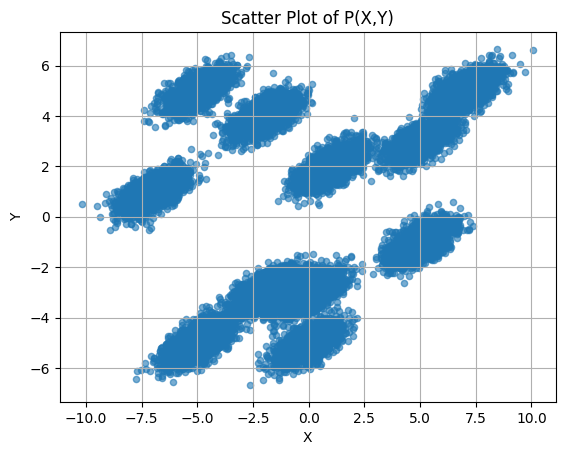

In [15]:
X = dist_utils.generate_mog_samples(25_000, mu_list, Sigma_list, alpha).float().to(device)
xh_cpu = X.detach().cpu().numpy()

# Scatter plot of first column vs. second column
plt.scatter(xh_cpu[:, 0], xh_cpu[:, 1], alpha=0.6, s=20)
plt.title("Scatter Plot of P(X,Y)")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

## Parameters for tests

In [20]:
## NN
nblocks=3
nunits=128
nepochs=20_000
batch_size=512

nepochs_CM=7_500
batch_size_CM=1024

## Diffusion
diffusion_steps=100

## Optimization
n_attemp_optim=3
nsamples_in_optim_for_mmd=250


# For models
condition_on=1
nfeatures= X.shape[1]

## Train

### Consistency Models

Train conditional model  - P(Y|X=x)

In [17]:
B, C = X.shape
nfeatures = C - condition_on

# Use the converted data
data_generator=partial(dist_utils.generate_mog_samples_not_differentiable, means=mu_list, variances=Sigma_list, weights=alpha)

Cos_ConsistencyModeliCT = ConsistencyModeliCT(nfeatures=nfeatures, condition_on=condition_on, nunits=128)
Cos_ConsistencyModeliCT.train_model(
    X=None,
    nepochs=nepochs_CM,
    batch_size=batch_size_CM,
    device=device,
    condition=condition_on,
    data_generator=data_generator,
    use_improved_training=True
)

loss: 0.328003, mu: 0.0000, N: 1281: 100%|██████████| 7500/7500 [01:09<00:00, 108.53it/s]


### Diffusion

Train conditional model P(Y|X=x)

In [18]:
## LGD
# init a model, train
X = dist_utils.generate_mog_samples(1_000, mu_list, Sigma_list, alpha).float().to(device)
nfeatures = X.shape[1]
condition_on = mu_list[0].shape[0] - mog_means[0].shape[0]
model_cond = Diffusion.DiffusionModel(nfeatures=nfeatures, nblocks=nblocks, nunits=nunits, condition=True,
                                      condition_on=condition_on, diffusion_steps=diffusion_steps)

data_generator=partial(dist_utils.generate_mog_samples_not_differentiable, means=mu_list, variances=Sigma_list, weights=alpha,kernel_func=None)
losses = model_cond.train_model(None,
                                data_generator=data_generator,
                                nepochs=nepochs, batch_size=batch_size, condition_on=condition_on)

loss: 0.316334: 100%|██████████| 20000/20000 [07:49<00:00, 42.61it/s]


Train unconditional model P(X=x)



In [19]:
# init a model, train
X_for_cond_only = X[:, :model_cond.condition_on]
nfeatures = X_for_cond_only.shape[1]

data_generator=partial(dist_utils.generate_mog_samples_not_differentiable, means=mu_list, variances=Sigma_list, weights=alpha,kernel_func=lambda X: X[:, :model_cond.condition_on])
model_uncond=Diffusion.DiffusionModel(nfeatures=nfeatures, nblocks=nblocks, nunits=nunits, condition=False,diffusion_steps=diffusion_steps)
losses = model_uncond.train_model(None,
                                  data_generator=data_generator,
                                  nepochs=nepochs
, batch_size=batch_size, condition_on=condition_on)


loss: 0.684539: 100%|██████████| 20000/20000 [06:33<00:00, 50.77it/s]


### Flow

In [26]:
input_dim =mog_means[0].shape[0]
condition_on = mu_list[0].shape[0]-mog_means[0].shape[0]
hidden_dim = nunits
depth = nblocks

Train conditional model P(Y|X=x)



In [27]:
vf_y_cond_x = FlowMatching.FMModel(nfeatures=input_dim,
                                   condition_on=condition_on,
                                   nunits=hidden_dim,
                                   nblocks=depth,
                                   device=device)

data_generator=partial(dist_utils.generate_mog_samples_not_differentiable, means=mu_list, variances=Sigma_list, weights=alpha,kernel_func=None)
vf_y_cond_x.train_FM(lr=0.001, batch_size=batch_size, nepochs=nepochs,data_generator=data_generator)



loss: 3.807985: 100%|██████████| 20000/20000 [04:32<00:00, 73.49it/s]


Train unconditional model P(X=x)



In [28]:
input_dim = mu_list[0].shape[0]-mog_means[0].shape[0]#first_column_x.shape[1]
vf_X = FlowMatching.FMModel(nfeatures=input_dim,
                                   condition_on=0,
                                   nunits=hidden_dim,
                                   nblocks=depth,
                                   device=device)
data_generator=partial(dist_utils.generate_mog_samples_not_differentiable, means=mu_list, variances=Sigma_list, weights=alpha,kernel_func=lambda X: X[:, :condition_on])

vf_X.train_FM(lr=0.001, batch_size=batch_size, nepochs=nepochs,
              data_generator=data_generator
              )



loss: 6.702595: 100%|██████████| 20000/20000 [02:47<00:00, 119.57it/s]


## Optimize

In [23]:
def gmm_l2_distance(mu_p, Sigma_p, w_p, mu_q, Sigma_q, w_q):
    """
    Exact L2 distance between two GMMs:
    ||p - q||^2 = <p,p> - 2<p,q> + <q,q>
    where <f,g> = integral f(x)g(x)dx, closed form for Gaussians.
    """
    import torch

    def gaussian_inner_product(mu1, S1, w1_list, mu2, S2, w2_list):
        # sum_{i,j} w1_i * w2_j * N(mu1_i; mu2_j, S1_i + S2_j)
        total = 0.0
        for mu_i, S_i, w_i in zip(mu1, S1, w1_list):
            for mu_j, S_j, w_j in zip(mu2, S2, w2_list):
                S_sum = S_i + S_j
                diff  = mu_i - mu_j
                d     = mu_i.shape[0]
                sign, logdet = torch.linalg.slogdet(S_sum)
                log_val = -0.5 * (d * torch.log(torch.tensor(2 * 3.14159265)) + logdet
                                  + diff @ torch.linalg.inv(S_sum) @ diff)
                total += w_i.item() * w_j.item() * torch.exp(log_val).item()
        return total

    pp = gaussian_inner_product(mu_p, Sigma_p, w_p, mu_p, Sigma_p, w_p)
    qq = gaussian_inner_product(mu_q, Sigma_q, w_q, mu_q, Sigma_q, w_q)
    pq = gaussian_inner_product(mu_p, Sigma_p, w_p, mu_q, Sigma_q, w_q)
    return pp - 2 * pq + qq

### LGD

In [32]:
best_x_t_LGD_list = []
l2_gmm_LGD_list   = []
l2_x_LGD_list     = []
lgd_times         = []
final_loss_LGD    = []

for i in trange(n_attemp_optim):
    start_time = time.time()
    best_x_t, best_x_0_cont_xt_hat, final_loss = Optimization.optimize_LGD(
        model_uncond, model_cond, mog_means, mog_variances, weights,
        mu_list, Sigma_list, alpha,
        nsamples=nsamples_in_optim_for_mmd, loss="MMD", device=device)
    end_time = time.time()
    lgd_times.append(end_time - start_time)
    final_loss_LGD.append(final_loss)
    best_x_t_LGD_list.append(best_x_t)

    x_pred_t = best_x_t.float().view(-1).cpu()
    mu_pred, Sigma_pred = dist_utils.compute_conditionals(mu_list, Sigma_list, x_pred_t)
    w_pred = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_pred_t)

    l2_gmm = gmm_l2_distance(mu_pred, Sigma_pred, w_pred, mog_means, mog_variances, weights)
    l2_x   = (x_pred_t - x_star.float().cpu()).pow(2).sum().sqrt().item()

    l2_gmm_LGD_list.append(l2_gmm)
    l2_x_LGD_list.append(l2_x)
    print(f"[{i+1}] L2 GMM: {l2_gmm:.6f}  |  L2 to x*: {l2_x:.6f}")

 33%|███▎      | 1/3 [02:18<04:37, 138.75s/it]

[1] L2 GMM: 0.004424  |  L2 to x*: 0.134109


 67%|██████▋   | 2/3 [04:55<02:29, 149.52s/it]

[2] L2 GMM: 0.000106  |  L2 to x*: 0.006705


100%|██████████| 3/3 [07:11<00:00, 143.90s/it]

[3] L2 GMM: 0.000713  |  L2 to x*: 0.048322


### LGD-CM

Run the optimization of the LGD-CM

In [33]:
best_x_t_LGD_CM_list = []
l2_gmm_LGD_CM_list   = []
l2_x_LGD_CM_list     = []
lgd_cm_times         = []
final_loss_LGD_CM    = []

for i in trange(n_attemp_optim):
    start_time = time.time()
    best_x_t, best_x_0_cont_xt_hat, final_loss = Optimization.optimize_LGD(
        model_uncond, Cos_ConsistencyModeliCT, mog_means, mog_variances, weights,
        mu_list, Sigma_list, alpha,
        nsamples=nsamples_in_optim_for_mmd, loss="MMD", device=device,
        CM=True, FLAG=False, num_x_t=3)
    end_time = time.time()
    lgd_cm_times.append(end_time - start_time)
    final_loss_LGD_CM.append(final_loss)
    best_x_t_LGD_CM_list.append(best_x_t)

    x_pred_t = best_x_t.float().view(-1).cpu()
    mu_pred, Sigma_pred = dist_utils.compute_conditionals(mu_list, Sigma_list, x_pred_t)
    w_pred = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_pred_t)

    l2_gmm = gmm_l2_distance(mu_pred, Sigma_pred, w_pred, mog_means, mog_variances, weights)
    l2_x   = (x_pred_t - x_star.float().cpu()).pow(2).sum().sqrt().item()

    l2_gmm_LGD_CM_list.append(l2_gmm)
    l2_x_LGD_CM_list.append(l2_x)
    print(f"[{i+1}] L2 GMM: {l2_gmm:.6f}  |  L2 to x*: {l2_x:.6f}")

 33%|███▎      | 1/3 [00:16<00:33, 16.61s/it]

[1] L2 GMM: 0.193039  |  L2 to x*: 0.957725


 67%|██████▋   | 2/3 [00:32<00:15, 15.92s/it]

[2] L2 GMM: 0.214735  |  L2 to x*: 1.023729


100%|██████████| 3/3 [00:47<00:00, 15.88s/it]

[3] L2 GMM: 0.213768  |  L2 to x*: 1.020776


### D-FLOW

In [34]:
x_optim_dflow_list    = []
l2_gmm_dflow_list     = []
l2_x_dflow_list       = []
dflow_times           = []
final_loss_dflow_list = []

for i in trange(n_attemp_optim):
    start_time = time.time()
    x_optim, final_loss = Optimization.optimize_DFLOW(
        vf_y_cond_x, vf_X, device, mog_means, mog_variances, weights,
        max_iter=100, FLAG=False, n_sample=nsamples_in_optim_for_mmd,
        loss_method="MMD", line_search_fn="strong_wolfe")
    end_time = time.time()
    dflow_times.append(end_time - start_time)
    final_loss_dflow_list.append(final_loss)
    x_optim_dflow_list.append(x_optim)

    x_pred_t = x_optim.float().view(-1).cpu()
    mu_pred, Sigma_pred = dist_utils.compute_conditionals(mu_list, Sigma_list, x_pred_t)
    w_pred = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_pred_t)

    l2_gmm = gmm_l2_distance(mu_pred, Sigma_pred, w_pred, mog_means, mog_variances, weights)
    l2_x   = (x_pred_t - x_star.float().cpu()).pow(2).sum().sqrt().item()

    l2_gmm_dflow_list.append(l2_gmm)
    l2_x_dflow_list.append(l2_x)
    print(f"[{i+1}] L2 GMM: {l2_gmm:.6f}  |  L2 to x*: {l2_x:.6f}")


 33%|███▎      | 1/3 [00:03<00:06,  3.29s/it]

[1] L2 GMM: 0.385744  |  L2 to x*: 11.170425


 67%|██████▋   | 2/3 [00:10<00:05,  5.53s/it]

[2] L2 GMM: 0.403127  |  L2 to x*: 3.944198


100%|██████████| 3/3 [00:12<00:00,  4.16s/it]

[3] L2 GMM: 0.339329  |  L2 to x*: 11.351397


In [35]:

def summary_row(name, l2_gmm, l2_x, times):
    return {
        "Method":               name,
        "L2 GMM mean":          f"{np.mean(l2_gmm):.4f}",
        "L2 GMM std":           f"{np.std(l2_gmm):.4f}",
        "L2 to x* mean":        f"{np.mean(l2_x):.4f}",
        "L2 to x* std":         f"{np.std(l2_x):.4f}",
        "Time mean (s)":        f"{np.mean(times):.2f}",
        "Time std (s)":         f"{np.std(times):.2f}",
    }

rows = [
    summary_row("LGD",     l2_gmm_LGD_list,    l2_x_LGD_list,    lgd_times),
    summary_row("LGD-CM",  l2_gmm_LGD_CM_list, l2_x_LGD_CM_list, lgd_cm_times),
    summary_row("D-Flow",  l2_gmm_dflow_list,  l2_x_dflow_list,  dflow_times),
]

df = pd.DataFrame(rows).set_index("Method")
display(df)

,L2 GMM mean,L2 GMM std,L2 to x* mean,L2 to x* std,Time mean (s),Time std (s)
Method,,,,,,
LGD,0.0017,0.0019,0.0630,0.0530,143.86,9.38
LGD-CM,0.2072,0.0100,1.0007,0.0304,15.85,0.52
D-Flow,0.3761,0.0269,8.8220,3.4499,4.12,2.14


## Summary - to 10

# 10D cond on 1D

## Parameters for tests

In [48]:
## NN
nblocks=5
nunits=128
nepochs=30_000
batch_size=512

nepochs_CM=7_500
batch_size_CM=4096

## Diffusion
diffusion_steps=100

## Optimization
n_attemp_optim=2
nsamples_in_optim_for_mmd=250

In [37]:
mu_list, Sigma_list, alpha,mog_means, mog_variances,weights,x_star= dist_utils.get_param_mog_with_target(dim_data=10,num_components=4,device='cpu',conditional_modes=2,distanceOrScale="Distance")
mog_means, mog_variances, weights= dist_utils.filter_and_normalize(mog_means, mog_variances, weights, threshold=0.001)

In [38]:
x_star

tensor([ -4.5404,   2.7114,   0.5513, -11.2950,   3.0335,  -0.6915,   4.1551,
         -1.2385,  -4.0147])

## Train

### Consistency Models

Train conditional model  - P(Y|X=x)

In [43]:
# init a model, train
X = dist_utils.generate_mog_samples(1_000, mu_list, Sigma_list, alpha).float().to(device)

condition_on=9
B, C = X.shape
nfeatures = C - condition_on
mu_list = [mu.float() for mu in mu_list]
Sigma_list = [cov.float() for cov in Sigma_list]
alpha = alpha.float()

data_generator=partial(dist_utils.generate_mog_samples_not_differentiable, means=mu_list, variances=Sigma_list, weights=alpha)

Cos_ConsistencyModeliCT = ConsistencyModeliCT(nfeatures=nfeatures, condition_on=condition_on, nunits=256)
Cos_ConsistencyModeliCT.train_model(X=None, nepochs=nepochs_CM
                      ,batch_size=batch_size_CM, device= device, condition=condition_on,
                      data_generator=data_generator,
                      )

loss: 0.303143, mu: 0.0000, N: 1281: 100%|██████████| 30000/30000 [05:26<00:00, 92.02it/s]


### Diffusion

Train conditional model P(Y|X=x)

In [46]:
# init a model, train
X = dist_utils.generate_mog_samples(1_000, mu_list, Sigma_list, alpha).float().to(device)
nfeatures = X.shape[1]
condition_on = mu_list[0].shape[0] - mog_means[0].shape[0]
model_cond = Diffusion.DiffusionModel(nfeatures=nfeatures, nblocks=nblocks, nunits=nunits, condition=True,
                                      condition_on=condition_on, diffusion_steps=diffusion_steps)

data_generator=partial(dist_utils.generate_mog_samples_not_differentiable, means=mu_list, variances=Sigma_list, weights=alpha,kernel_func=None)
losses = model_cond.train_model(None,
                                data_generator=data_generator,
                                nepochs=nepochs, batch_size=batch_size, condition_on=condition_on)

loss: 0.193495: 100%|██████████| 30000/30000 [16:23<00:00, 30.51it/s]


Train uncnditional model P(X=x)

In [47]:
# init a model, train
X_for_cond_only = X[:, :model_cond.condition_on]
nfeatures = X_for_cond_only.shape[1]

data_generator=partial(dist_utils.generate_mog_samples_not_differentiable, means=mu_list, variances=Sigma_list, weights=alpha,kernel_func=lambda X: X[:, :model_cond.condition_on])
model_uncond=Diffusion.DiffusionModel(nfeatures=nfeatures, nblocks=nblocks, nunits=nunits, condition=False,diffusion_steps=diffusion_steps)
losses = model_uncond.train_model(None,
                                  data_generator=data_generator,
                                  nepochs=nepochs
, batch_size=batch_size, condition_on=condition_on)


loss: 0.708928: 100%|██████████| 30000/30000 [14:13<00:00, 35.15it/s]


### Optimize

#### Regular

100%|██████████| 2/2 [06:03<00:00, 181.96s/it]

[tensor([[ -4.9997],
        [  2.2662],
        [ -1.0819],
        [-11.1004],
        [  2.6843],
        [  2.2221],
        [  2.6248],
        [ -0.8740],
        [ -4.2631]], device='cuda:0'), tensor([[ -5.4656],
        [  2.5760],
        [ -1.6543],
        [-11.5404],
        [  3.0099],
        [  2.2446],
        [  4.0496],
        [ -0.7825],
        [ -4.1565]], device='cuda:0')]
[tensor(0.8657), tensor(0.5097)]
[np.float32(0.74197096), np.float32(0.44590607)]


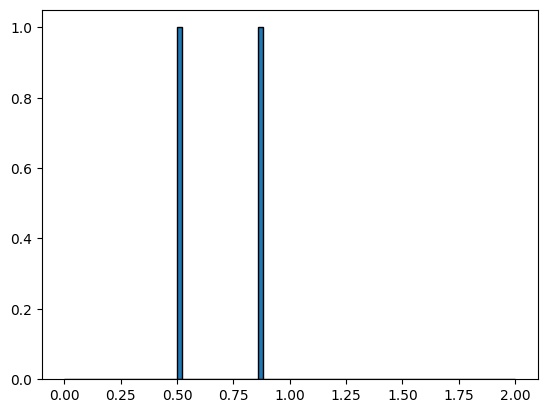

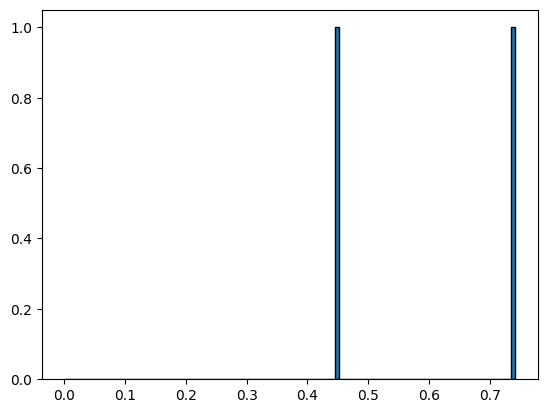

In [49]:
best_x_t_LGD_list=[]
l1_distance_LGD_list=[]
EMD_distance_LGD_list=[]
norm_swd_LGD_list=[]

lgd_times = []
final_loss_LGD=[]
swd_LGD_list=[]

for i in trange(n_attemp_optim):
    start_time = time.time()
    best_x_t, best_x_0_cont_xt_hat, final_loss = Optimization.optimize_LGD(model_uncond, model_cond, mog_means, mog_variances, weights, mu_list, Sigma_list, alpha, nsamples=nsamples_in_optim_for_mmd, loss="MMD", device=device)
    best_x_t=best_x_t.reshape(-1,1)
    end_time = time.time()
    lgd_times.append(end_time - start_time)

    best_x_t_LGD_list.append(best_x_t)

    l1_distance = dist_utils.warpper_L1_distance(best_x_t, mu_list, Sigma_list, alpha, mog_means, mog_variances, weights)
    EMD_distance = dist_utils.compute_mixture_wasserstein_distance_1D(mu_list, Sigma_list, alpha, x_star, best_x_t,x_range=(-5, 15), n_points=1000)["wasserstein_distance"]
    swd,norm_swd = LossFunctions.compute_swd(
          best_x0_sample=best_x_t,
          mu_list=mu_list,
          Sigma_list=Sigma_list,
          alpha=alpha,
          mog_means=mog_means,
          mog_variances=mog_variances,
          weights=weights,
          decoder=None,
          scaler=None,
          device="cpu",
          nsamples=10_000,
          num_projections=1_000,
          p=2,
          Flag=False
      )
    l1_distance_LGD_list.append(l1_distance)
    norm_swd_LGD_list.append(norm_swd)
    swd_LGD_list.append(swd)
    final_loss_LGD.append(final_loss)


print(best_x_t_LGD_list)
print(l1_distance_LGD_list)
print(norm_swd_LGD_list)

plt.hist(l1_distance_LGD_list,  edgecolor='black',range=(0,2),bins=100,)
plt.show()

plt.hist(norm_swd_LGD_list,  edgecolor='black',range=(0, max(norm_swd_LGD_list)),bins=100,)
plt.show()

 50%|█████     | 1/2 [02:57<02:57, 177.86s/it]

[1] L2 GMM: 0.723164  |  L2 to x*: 21.847031


100%|██████████| 2/2 [05:56<00:00, 178.08s/it]

[2] L2 GMM: 0.019867  |  L2 to x*: 3.979702
[tensor([[-2.3664],
        [-6.8599],
        [-8.1415],
        [ 0.2212],
        [ 5.4804],
        [ 2.0426],
        [-7.1713],
        [-5.9472],
        [-6.9889]], device='cuda:0'), tensor([[ -5.5375],
        [  3.1242],
        [ -1.8101],
        [-11.7502],
        [  3.9408],
        [  1.7521],
        [  5.4720],
        [ -0.8204],
        [ -4.4462]], device='cuda:0')]
[0.7231637564621404, 0.019866588860457057]
[21.847030639648438, 3.9797024726867676]


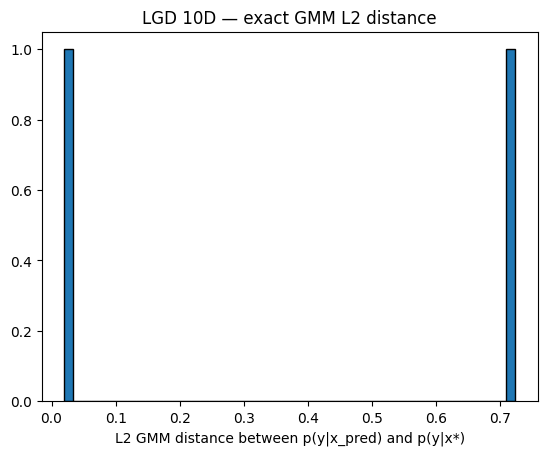

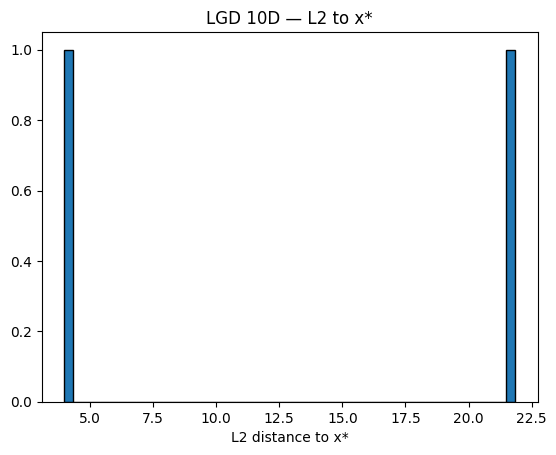

In [50]:
best_x_t_LGD_list = []
l2_gmm_LGD_list   = []
l2_x_LGD_list     = []
lgd_times         = []
final_loss_LGD    = []

for i in trange(n_attemp_optim):
    start_time = time.time()
    best_x_t, best_x_0_cont_xt_hat, final_loss = Optimization.optimize_LGD(
        model_uncond, model_cond, mog_means, mog_variances, weights,
        mu_list, Sigma_list, alpha,
        nsamples=nsamples_in_optim_for_mmd, loss="MMD", device=device)
    best_x_t = best_x_t.reshape(-1, 1)
    end_time = time.time()
    lgd_times.append(end_time - start_time)
    final_loss_LGD.append(final_loss)
    best_x_t_LGD_list.append(best_x_t)

    x_pred_t = best_x_t.float().view(-1).cpu()
    mu_pred, Sigma_pred = dist_utils.compute_conditionals(mu_list, Sigma_list, x_pred_t)
    w_pred = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_pred_t)

    l2_gmm = gmm_l2_distance(mu_pred, Sigma_pred, w_pred, mog_means, mog_variances, weights)
    l2_x   = (x_pred_t - x_star.float().cpu()).pow(2).sum().sqrt().item()

    l2_gmm_LGD_list.append(l2_gmm)
    l2_x_LGD_list.append(l2_x)
    print(f"[{i+1}] L2 GMM: {l2_gmm:.6f}  |  L2 to x*: {l2_x:.6f}")

print(best_x_t_LGD_list)
print(l2_gmm_LGD_list)
print(l2_x_LGD_list)

plt.hist(l2_gmm_LGD_list, edgecolor='black', bins=50)
plt.xlabel("L2 GMM distance between p(y|x_pred) and p(y|x*)")
plt.title("LGD 10D — exact GMM L2 distance")
plt.show()

plt.hist(l2_x_LGD_list, edgecolor='black', bins=50)
plt.xlabel("L2 distance to x*")
plt.title("LGD 10D — L2 to x*")
plt.show()

### Optimize

#### CM

 50%|█████     | 1/2 [01:07<01:07, 67.65s/it]

tensor(0.8915)
0.6888094


100%|██████████| 2/2 [02:14<00:00, 67.49s/it]

tensor(0.8931)
0.6800512
[tensor([[ 19.0338],
        [-13.4161],
        [ 13.4178],
        [ -2.1946],
        [ -0.1755],
        [  4.8707],
        [  3.7744],
        [ 17.3963],
        [  7.1955]], device='cuda:0'), tensor([[ 18.9452],
        [-13.4786],
        [ 13.8709],
        [ -2.0636],
        [ -0.4349],
        [  5.3287],
        [  4.6416],
        [ 17.6412],
        [  7.7272]], device='cuda:0')]
[tensor(0.8915), tensor(0.8931)]
[np.float32(0.6888094), np.float32(0.6800512)]


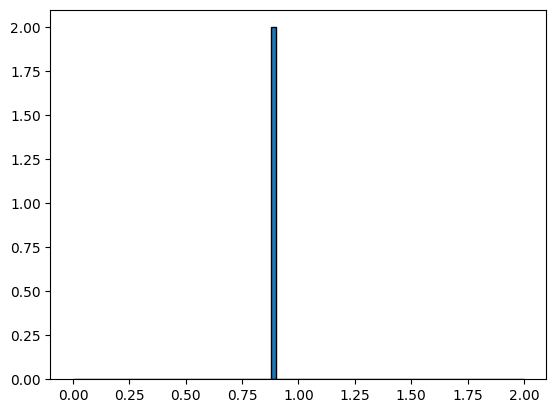

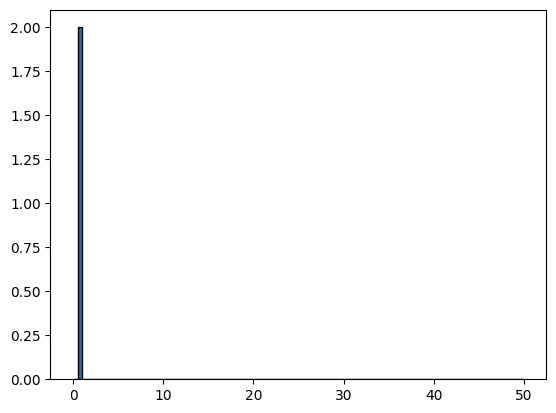

In [51]:
best_x_t_LGD_CM_list=[]
l1_distance_LGD_CM_list=[]
norm_swd_LGD_CM_list=[]
lgd_cm_times = []
final_loss_LGD_CM=[]
swd_LGD_CM_list=[]

for i in trange(n_attemp_optim):
    start_time = time.time()
    best_x_t, best_x_0_cont_xt_hat, final_loss = Optimization.optimize_LGD(model_uncond, Cos_ConsistencyModeliCT, mog_means, mog_variances, weights, mu_list, Sigma_list, alpha, nsamples=nsamples_in_optim_for_mmd, loss="MMD", device=device, CM=True, FLAG=False,num_x_t=10)
    end_time = time.time()
    best_x_t=best_x_t.reshape(-1,1)
    lgd_cm_times.append(end_time - start_time)
    best_x_t_LGD_CM_list.append(best_x_t)

    l1_distance = dist_utils.warpper_L1_distance(best_x_t, mu_list, Sigma_list, alpha, mog_means, mog_variances, weights)
    swd,norm_swd =  LossFunctions.compute_swd(
        best_x0_sample=best_x_t,
        mu_list=mu_list,
        Sigma_list=Sigma_list,
        alpha=alpha,
        mog_means=mog_means,
        mog_variances=mog_variances,
        weights=weights,
        decoder=None,
        scaler=None,
        device="cpu",
        nsamples=10_000,
        num_projections=1_000,
        p=2,
        Flag=False
    )
    print(l1_distance)
    print(norm_swd)
    l1_distance_LGD_CM_list.append(l1_distance)
    norm_swd_LGD_CM_list.append(norm_swd)
    swd_LGD_CM_list.append(swd)
    final_loss_LGD_CM.append(final_loss)

print(best_x_t_LGD_CM_list)
print(l1_distance_LGD_CM_list)
print(norm_swd_LGD_CM_list)

plt.hist(l1_distance_LGD_CM_list,  edgecolor='black',range=(0,2),bins=100,)
plt.show()

plt.hist(norm_swd_LGD_CM_list,  edgecolor='black', range=(0,50),bins=100,)
plt.show()

In [ ]:
# ── LGD-CM ────────────────────────────────────────────────────────────────────
best_x_t_LGD_CM_list = []
l2_gmm_LGD_CM_list   = []
l2_x_LGD_CM_list     = []
lgd_cm_times         = []
final_loss_LGD_CM    = []

for i in trange(n_attemp_optim):
    start_time = time.time()
    best_x_t, best_x_0_cont_xt_hat, final_loss = Optimization.optimize_LGD(
        model_uncond, Cos_ConsistencyModeliCT, mog_means, mog_variances, weights,
        mu_list, Sigma_list, alpha,
        nsamples=nsamples_in_optim_for_mmd, loss="MMD", device=device,
        CM=True, FLAG=False, num_x_t=10)
    best_x_t = best_x_t.reshape(-1, 1)
    end_time = time.time()
    lgd_cm_times.append(end_time - start_time)
    final_loss_LGD_CM.append(final_loss)
    best_x_t_LGD_CM_list.append(best_x_t)

    x_pred_t = best_x_t.float().view(-1).cpu()
    mu_pred, Sigma_pred = dist_utils.compute_conditionals(mu_list, Sigma_list, x_pred_t)
    w_pred = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_pred_t)

    l2_gmm = gmm_l2_distance(mu_pred, Sigma_pred, w_pred, mog_means, mog_variances, weights)
    l2_x   = (x_pred_t - x_star.float().cpu()).pow(2).sum().sqrt().item()

    l2_gmm_LGD_CM_list.append(l2_gmm)
    l2_x_LGD_CM_list.append(l2_x)
    print(f"[{i+1}] L2 GMM: {l2_gmm:.6f}  |  L2 to x*: {l2_x:.6f}")


In [52]:
print(f"final_loss_LGD_CM:",final_loss_LGD_CM)
print("swd_LGD_CM_list",swd_LGD_CM_list)

final_loss_LGD_CM: [tensor(0.6385, dtype=torch.float64), tensor(0.6111, dtype=torch.float64)]
swd_LGD_CM_list [np.float32(1.4777607), np.float32(1.458971)]


## Flow

### Train

In [53]:
input_dim =mog_means[0].shape[0]
y_dim = mu_list[0].shape[0]-mog_means[0].shape[0]
hidden_dim = nunits
depth = nblocks


In [ ]:
vf_y_cond_x = FlowMatching.FMModel(nfeatures=input_dim,
                                   condition_on=condition_on,
                                   nunits=hidden_dim,
                                   nblocks=depth,
                                   device=device)

data_generator=partial(dist_utils.generate_mog_samples_not_differentiable, means=mu_list, variances=Sigma_list, weights=alpha,kernel_func=None)
vf_y_cond_x.train_FM(lr=0.001, batch_size=batch_size, nepochs=nepochs,data_generator=data_generator)



loss: 1.956515:  62%|██████▏   | 18532/30000 [05:28<02:58, 64.38it/s]

In [ ]:

input_dim = mu_list[0].shape[0]-mog_means[0].shape[0]#first_column_x.shape[1]
vf_X = FlowMatching.FMModel(nfeatures=input_dim,
                                   condition_on=0,
                                   nunits=hidden_dim,
                                   nblocks=depth,
                                   device=device)
data_generator=partial(dist_utils.generate_mog_samples_not_differentiable, means=mu_list, variances=Sigma_list, weights=alpha,kernel_func=lambda X: X[:, :condition_on])

vf_X.train_FM(lr=0.001, batch_size=batch_size, nepochs=nepochs,
              data_generator=data_generator
              )

### Optimize

#### Regular

In [ ]:
best_x_t_dflow_list=[]
l1_distance_dflow_list=[]
EMD_distance_dflow_list=[]
dflow_times = []
final_loss_dflow_list=[]
norm_swd_dflow_list=[]
swd_dflow_list=[]

for i in trange(n_attemp_optim):
    start_time = time.time()
    x_optim,  final_loss = Optimization.optimize_DFLOW(vf_y_cond_x, vf_X, device, mog_means, mog_variances, weights, max_iter=100, FLAG=False, n_sample=nsamples_in_optim_for_mmd, loss_method="MMD", line_search_fn="strong_wolfe")
    end_time = time.time()
    x_optim=x_optim.reshape(-1,1)
    dflow_times.append(end_time - start_time)

    best_x_t_dflow_list.append(x_optim)

    l1_distance = dist_utils.warpper_L1_distance(x_optim, mu_list, Sigma_list, alpha, mog_means, mog_variances, weights)
    EMD_distance = dist_utils.compute_mixture_wasserstein_distance_1D(mu_list, Sigma_list, alpha, x_star, x_optim,x_range=(-5, 15), n_points=1000)["wasserstein_distance"]
    swd,norm_swd = LossFunctions.compute_swd(
            best_x0_sample=x_optim,
            mu_list=mu_list,
            Sigma_list=Sigma_list,
            alpha=alpha,
            mog_means=mog_means,
            mog_variances=mog_variances,
            weights=weights,
            decoder=None,
            scaler=None,
            device="cpu",
            nsamples=10_000,
            num_projections=1_000,
            p=2,
            Flag=False
        )
    l1_distance_dflow_list.append(l1_distance)
    norm_swd_dflow_list.append(norm_swd)
    swd_dflow_list.append(swd)
    final_loss_dflow_list.append(final_loss)

l1_distance_dflow_list = [tensor.detach().cpu().numpy() if hasattr(tensor, 'detach') else tensor for tensor in l1_distance_dflow_list]
# EMD_distance_dflow_list = [tensor.detach().cpu().numpy() if hasattr(tensor, 'detach') else tensor for tensor in EMD_distance_dflow_list]


print(best_x_t_dflow_list)
print(l1_distance_dflow_list)

plt.hist(l1_distance_dflow_list,  edgecolor='black',range=(0,2),bins=100,)
plt.show()

plt.hist(norm_swd_dflow_list,  edgecolor='black',range=(0, max(norm_swd_dflow_list)),bins=100,)
plt.show()


In [ ]:
# ── D-Flow ────────────────────────────────────────────────────────────────────
x_optim_dflow_list    = []
l2_gmm_dflow_list     = []
l2_x_dflow_list       = []
dflow_times           = []
final_loss_dflow_list = []

for i in trange(n_attemp_optim):
    start_time = time.time()
    x_optim, final_loss = Optimization.optimize_DFLOW(
        vf_y_cond_x, vf_X, device, mog_means, mog_variances, weights,
        max_iter=100, FLAG=False, n_sample=nsamples_in_optim_for_mmd,
        loss_method="MMD", line_search_fn="strong_wolfe")
    x_optim = x_optim.reshape(-1, 1)
    end_time = time.time()
    dflow_times.append(end_time - start_time)
    final_loss_dflow_list.append(final_loss)
    x_optim_dflow_list.append(x_optim)

    x_pred_t = x_optim.float().view(-1).cpu()
    mu_pred, Sigma_pred = dist_utils.compute_conditionals(mu_list, Sigma_list, x_pred_t)
    w_pred = dist_utils.compute_alpha(mu_list, Sigma_list, alpha, x_pred_t)

    l2_gmm = gmm_l2_distance(mu_pred, Sigma_pred, w_pred, mog_means, mog_variances, weights)
    l2_x   = (x_pred_t - x_star.float().cpu()).pow(2).sum().sqrt().item()

    l2_gmm_dflow_list.append(l2_gmm)
    l2_x_dflow_list.append(l2_x)
    print(f"[{i+1}] L2 GMM: {l2_gmm:.6f}  |  L2 to x*: {l2_x:.6f}")



In [ ]:

rows = [
    summary_row("LGD",     l2_gmm_LGD_list,    l2_x_LGD_list,    lgd_times),
    summary_row("LGD-CM",  l2_gmm_LGD_CM_list, l2_x_LGD_CM_list, lgd_cm_times),
    summary_row("D-Flow",  l2_gmm_dflow_list,  l2_x_dflow_list,  dflow_times),
]

df = pd.DataFrame(rows).set_index("Method")
display(df)